# 11 — Lightweight Mel CNN Baseline

Optional PyTorch experiment. Uses patient-disjoint train/validation/test splits; class weights are fit from training labels, early stopping and LR reduction use validation loss, and only training cycles receive noise/time-shift augmentation. If the optional framework is unavailable, install only the optional requirements file.

In [ ]:
from pathlib import Path
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.1


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DL_DIR = PROCESSED_DIR / "deep_learning"

NOTEBOOK_OUTPUT_DIR = DL_DIR / "cnn_baseline"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

print("DL_DIR:", DL_DIR)
print("Output directory:", NOTEBOOK_OUTPUT_DIR)

DL_DIR: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning
Output directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline


In [7]:
manifest_path = DL_DIR / "deep_learning_manifest.csv"

dl_manifest = pd.read_csv(manifest_path)

print("Manifest shape:", dl_manifest.shape)
print("Unique patients:", dl_manifest["patient_id"].nunique())
print("Unique cycles:", len(dl_manifest))

display(dl_manifest.head())

Manifest shape: (6898, 7)
Unique patients: 126
Unique cycles: 6898


,patient_id,recording_id,chest_location,diagnosis,disease_label,official_split,audio_path
0,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
1,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
2,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
3,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
4,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...


In [8]:
patient_diagnosis = (
    dl_manifest
    .groupby("patient_id")["diagnosis"]
    .nunique()
)

print(
    "Patients with exactly one diagnosis:",
    (patient_diagnosis == 1).sum()
)

print(
    "Patients with multiple diagnoses:",
    (patient_diagnosis > 1).sum()
)

assert (patient_diagnosis == 1).all()

patient_df = (
    dl_manifest[
        ["patient_id", "diagnosis"]
    ]
    .drop_duplicates()
    .sort_values("patient_id")
    .reset_index(drop=True)
)

print("\nPatient-level dataset shape:", patient_df.shape)

display(patient_df.head())

Patients with exactly one diagnosis: 126
Patients with multiple diagnoses: 0

Patient-level dataset shape: (126, 2)


,patient_id,diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [9]:
patient_counts = (
    patient_df["diagnosis"]
    .value_counts()
    .sort_index()
)

display(
    patient_counts
    .rename_axis("diagnosis")
    .reset_index(name="patients")
)

,diagnosis,patients
0,Asthma,1
1,Bronchiectasis,7
2,Bronchiolitis,6
3,COPD,64
4,Healthy,26
5,LRTI,2
6,Pneumonia,6
7,URTI,14


In [11]:
print("Patient-level disease distribution:")
display(
    patient_df["diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("diagnosis")
    .reset_index(name="patients")
)

Patient-level disease distribution:


,diagnosis,patients
0,Asthma,1
1,Bronchiectasis,7
2,Bronchiolitis,6
3,COPD,64
4,Healthy,26
5,LRTI,2
6,Pneumonia,6
7,URTI,14


In [12]:
patient_class_counts = (
    patient_df["diagnosis"]
    .value_counts()
    .sort_index()
)

rare_classes = patient_class_counts[
    patient_class_counts < 3
].index.tolist()

print("Rare classes:", rare_classes)
print(
    patient_class_counts[
        patient_class_counts < 3
    ]
)

Rare classes: ['Asthma', 'LRTI']
diagnosis
Asthma    1
LRTI      2
Name: count, dtype: int64


In [13]:
rare_patients = patient_df[
    patient_df["diagnosis"].isin(rare_classes)
].copy()

regular_patients = patient_df[
    ~patient_df["diagnosis"].isin(rare_classes)
].copy()

print("Rare-class patients:", len(rare_patients))
print("Regular patients:", len(regular_patients))

display(rare_patients)

Rare-class patients: 3
Regular patients: 123


,patient_id,diagnosis
2,103,Asthma
7,108,LRTI
14,115,LRTI


In [14]:
train_val_regular, test_regular = train_test_split(
    regular_patients,
    test_size=0.20,
    random_state=SEED,
    stratify=regular_patients["diagnosis"]
)

train_regular, val_regular = train_test_split(
    train_val_regular,
    test_size=0.1875,
    random_state=SEED,
    stratify=train_val_regular["diagnosis"]
)

print("Regular train:", len(train_regular))
print("Regular validation:", len(val_regular))
print("Regular test:", len(test_regular))

Regular train: 79
Regular validation: 19
Regular test: 25


In [15]:
train_patients = pd.concat(
    [
        train_regular,
        rare_patients
    ],
    ignore_index=True
)

val_patients = val_regular.copy()
test_patients = test_regular.copy()

print("Final patient counts:")
print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Final patient counts:
Train: 82
Validation: 19
Test: 25


In [16]:
print("Training disease distribution:")
display(
    train_patients["diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("diagnosis")
    .reset_index(name="patients")
)

print("\nValidation disease distribution:")
display(
    val_patients["diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("diagnosis")
    .reset_index(name="patients")
)

print("\nTest disease distribution:")
display(
    test_patients["diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("diagnosis")
    .reset_index(name="patients")
)

Training disease distribution:


,diagnosis,patients
0,Asthma,1
1,Bronchiectasis,4
2,Bronchiolitis,4
3,COPD,41
4,Healthy,17
5,LRTI,2
6,Pneumonia,4
7,URTI,9



Validation disease distribution:


,diagnosis,patients
0,Bronchiectasis,1
1,Bronchiolitis,1
2,COPD,10
3,Healthy,4
4,Pneumonia,1
5,URTI,2



Test disease distribution:


,diagnosis,patients
0,Bronchiectasis,2
1,Bronchiolitis,1
2,COPD,13
3,Healthy,5
4,Pneumonia,1
5,URTI,3


In [17]:
train_patient_ids = set(train_patients["patient_id"])
val_patient_ids = set(val_patients["patient_id"])
test_patient_ids = set(test_patients["patient_id"])

assert train_patient_ids.isdisjoint(val_patient_ids)
assert train_patient_ids.isdisjoint(test_patient_ids)
assert val_patient_ids.isdisjoint(test_patient_ids)

print("Patient-disjoint split verified.")

Patient-disjoint split verified.


In [18]:
dl_manifest["cnn_split"] = "unassigned"

dl_manifest.loc[
    dl_manifest["patient_id"].isin(train_patient_ids),
    "cnn_split"
] = "train"

dl_manifest.loc[
    dl_manifest["patient_id"].isin(val_patient_ids),
    "cnn_split"
] = "validation"

dl_manifest.loc[
    dl_manifest["patient_id"].isin(test_patient_ids),
    "cnn_split"
] = "test"

print(dl_manifest["cnn_split"].value_counts())

cnn_split
train         4423
test          1561
validation     914
Name: count, dtype: int64


In [19]:
assert (dl_manifest["cnn_split"] != "unassigned").all()

print("All cycles assigned successfully.")

All cycles assigned successfully.


In [20]:
split_summary = (
    dl_manifest
    .groupby("cnn_split")
    .agg(
        cycles=("patient_id", "size"),
        patients=("patient_id", "nunique")
    )
    .reindex(["train", "validation", "test"])
    .reset_index()
)

display(split_summary)

,cnn_split,cycles,patients
0,train,4423,82
1,validation,914,19
2,test,1561,25


In [21]:
cycle_disease_distribution = pd.crosstab(
    dl_manifest["cnn_split"],
    dl_manifest["diagnosis"]
)

display(cycle_disease_distribution)

diagnosis,Asthma,Bronchiectasis,Bronchiolitis,COPD,Healthy,LRTI,Pneumonia,URTI
cnn_split,,,,,,,,
test,0,20,19,1337,84,0,52,49
train,6,76,114,3713,194,32,121,167
validation,0,8,27,696,44,0,112,27


In [22]:
split_patient_sets = {
    split: set(
        dl_manifest.loc[
            dl_manifest["cnn_split"] == split,
            "patient_id"
        ]
    )
    for split in ["train", "validation", "test"]
}

assert split_patient_sets["train"].isdisjoint(
    split_patient_sets["validation"]
)

assert split_patient_sets["train"].isdisjoint(
    split_patient_sets["test"]
)

assert split_patient_sets["validation"].isdisjoint(
    split_patient_sets["test"]
)

print("FINAL PATIENT LEAKAGE CHECK PASSED")

FINAL PATIENT LEAKAGE CHECK PASSED


In [23]:
train_cnn_manifest = (
    dl_manifest[
        dl_manifest["cnn_split"] == "train"
    ]
    .reset_index(drop=True)
)

val_cnn_manifest = (
    dl_manifest[
        dl_manifest["cnn_split"] == "validation"
    ]
    .reset_index(drop=True)
)

test_cnn_manifest = (
    dl_manifest[
        dl_manifest["cnn_split"] == "test"
    ]
    .reset_index(drop=True)
)

print("Train:", train_cnn_manifest.shape)
print("Validation:", val_cnn_manifest.shape)
print("Test:", test_cnn_manifest.shape)

Train: (4423, 8)
Validation: (914, 8)
Test: (1561, 8)


In [24]:
train_cnn_manifest_path = (
    NOTEBOOK_OUTPUT_DIR / "train_cnn_manifest.csv"
)

val_cnn_manifest_path = (
    NOTEBOOK_OUTPUT_DIR / "validation_cnn_manifest.csv"
)

test_cnn_manifest_path = (
    NOTEBOOK_OUTPUT_DIR / "test_cnn_manifest.csv"
)

train_cnn_manifest.to_csv(
    train_cnn_manifest_path,
    index=False
)

val_cnn_manifest.to_csv(
    val_cnn_manifest_path,
    index=False
)

test_cnn_manifest.to_csv(
    test_cnn_manifest_path,
    index=False
)

print("Saved:")
print(train_cnn_manifest_path)
print(val_cnn_manifest_path)
print(test_cnn_manifest_path)

Saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/train_cnn_manifest.csv
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/validation_cnn_manifest.csv
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/test_cnn_manifest.csv


In [25]:
cnn_manifest_path = (
    NOTEBOOK_OUTPUT_DIR / "cnn_patient_disjoint_manifest.csv"
)

dl_manifest.to_csv(
    cnn_manifest_path,
    index=False
)

print("Complete CNN manifest saved to:")
print(cnn_manifest_path)

Complete CNN manifest saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_patient_disjoint_manifest.csv


In [26]:
split_summary_path = (
    NOTEBOOK_OUTPUT_DIR / "cnn_split_summary.csv"
)

split_summary.to_csv(
    split_summary_path,
    index=False
)

print("Split summary saved to:")
print(split_summary_path)

Split summary saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_split_summary.csv


In [27]:
X_train_official = np.load(
    DL_DIR / "X_train_logmel.npy",
    mmap_mode="r"
)

X_test_official = np.load(
    DL_DIR / "X_test_logmel.npy",
    mmap_mode="r"
)

y_train_official = np.load(
    DL_DIR / "y_train.npy"
)

y_test_official = np.load(
    DL_DIR / "y_test.npy"
)

print("Official training array:", X_train_official.shape)
print("Official testing array:", X_test_official.shape)

print("Official training labels:", y_train_official.shape)
print("Official testing labels:", y_test_official.shape)

Official training array: (4142, 64, 157)
Official testing array: (2756, 64, 157)
Official training labels: (4142,)
Official testing labels: (2756,)


In [28]:
print("Train example:")
display(train_cnn_manifest.head(3))

print("\nValidation example:")
display(val_cnn_manifest.head(3))

print("\nTest example:")
display(test_cnn_manifest.head(3))

Train example:


,patient_id,recording_id,chest_location,diagnosis,disease_label,official_split,audio_path,cnn_split
0,102,1b1,Ar,Healthy,4,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,train
1,102,1b1,Ar,Healthy,4,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,train
2,102,1b1,Ar,Healthy,4,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,train



Validation example:


,patient_id,recording_id,chest_location,diagnosis,disease_label,official_split,audio_path,cnn_split
0,109,1b1,Al,COPD,3,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,validation
1,109,1b1,Al,COPD,3,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,validation
2,109,1b1,Al,COPD,3,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,validation



Test example:


,patient_id,recording_id,chest_location,diagnosis,disease_label,official_split,audio_path,cnn_split
0,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
1,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
2,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test


In [29]:
def check_audio_paths(manifest):
    return manifest["audio_path"].apply(
        lambda p: Path(p).exists()
    )

train_audio_exists = check_audio_paths(train_cnn_manifest)
val_audio_exists = check_audio_paths(val_cnn_manifest)
test_audio_exists = check_audio_paths(test_cnn_manifest)

print("Train missing:", (~train_audio_exists).sum())
print("Validation missing:", (~val_audio_exists).sum())
print("Test missing:", (~test_audio_exists).sum())

assert train_audio_exists.all()
assert val_audio_exists.all()
assert test_audio_exists.all()

print("\nAll CNN audio paths are valid.")

Train missing: 0
Validation missing: 0
Test missing: 0

All CNN audio paths are valid.


In [32]:
class_mapping_path = DL_DIR / "disease_class_mapping.csv"

class_mapping = pd.read_csv(class_mapping_path)

print("Class mapping:")
display(class_mapping)

Class mapping:


,disease_label,diagnosis
0,0,Asthma
1,1,Bronchiectasis
2,2,Bronchiolitis
3,3,COPD
4,4,Healthy
5,5,LRTI
6,6,Pneumonia
7,7,URTI


In [33]:
for name, manifest in [
    ("train", train_cnn_manifest),
    ("validation", val_cnn_manifest),
    ("test", test_cnn_manifest)
]:
    diagnosis_from_label = (
        class_mapping
        .set_index("disease_label")
        .loc[manifest["disease_label"], "diagnosis"]
        .to_numpy()
    )

    assert np.array_equal(
        diagnosis_from_label,
        manifest["diagnosis"].to_numpy()
    )

    print(f"{name}: label mapping verified.")

train: label mapping verified.
validation: label mapping verified.
test: label mapping verified.


In [35]:
# Log-Mel configuration used in Notebook 10

TARGET_SR = 4000
TARGET_DURATION = 5.0
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)

N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64
FMIN = 0
FMAX = 2000

print("Log-Mel configuration restored.")
print("Target sampling rate:", TARGET_SR)
print("Target duration:", TARGET_DURATION)
print("Target samples:", TARGET_SAMPLES)
print("N_FFT:", N_FFT)
print("Hop length:", HOP_LENGTH)
print("N_MELS:", N_MELS)
print("FMIN:", FMIN)
print("FMAX:", FMAX)

Log-Mel configuration restored.
Target sampling rate: 4000
Target duration: 5.0
Target samples: 20000
N_FFT: 512
Hop length: 128
N_MELS: 64
FMIN: 0
FMAX: 2000


In [37]:
print("CNN split:")
print(dl_manifest["cnn_split"].value_counts())

print("\nPatients:")
print(
    dl_manifest.groupby("cnn_split")["patient_id"]
    .nunique()
)

print("\nPatient overlap checks:")

for split_a, split_b in [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test")
]:
    patients_a = set(
        dl_manifest.loc[
            dl_manifest["cnn_split"] == split_a,
            "patient_id"
        ]
    )

    patients_b = set(
        dl_manifest.loc[
            dl_manifest["cnn_split"] == split_b,
            "patient_id"
        ]
    )

    overlap = patients_a.intersection(patients_b)

    print(f"{split_a} vs {split_b}: {len(overlap)} overlapping patients")
    assert len(overlap) == 0

print("\nPatient-disjoint CNN split confirmed.")

CNN split:
cnn_split
train         4423
test          1561
validation     914
Name: count, dtype: int64

Patients:
cnn_split
test          25
train         82
validation    19
Name: patient_id, dtype: int64

Patient overlap checks:
train vs validation: 0 overlapping patients
train vs test: 0 overlapping patients
validation vs test: 0 overlapping patients

Patient-disjoint CNN split confirmed.


In [38]:
import soundfile as sf
import librosa

from torch.utils.data import Dataset, DataLoader

print("soundfile version:", sf.__version__)
print("librosa version:", librosa.__version__)

soundfile version: 0.14.0
librosa version: 1.0.0


In [40]:
normalization_path = DL_DIR / "logmel_train_normalization.csv"

normalization_df = pd.read_csv(normalization_path)

display(normalization_df)

,statistic,value
0,mean,-66.740814
1,std,17.337090


In [41]:
train_mean = float(
    normalization_df.loc[
        normalization_df["statistic"] == "mean",
        "value"
    ].iloc[0]
)

train_std = float(
    normalization_df.loc[
        normalization_df["statistic"] == "std",
        "value"
    ].iloc[0]
)

print("Training mean:", train_mean)
print("Training std:", train_std)

assert np.isfinite(train_mean)
assert np.isfinite(train_std)
assert train_std > 0

Training mean: -66.74081420898438
Training std: 17.33708953857422


In [42]:
def fix_audio_length(signal, target_samples):
    if len(signal) < target_samples:
        signal = np.pad(
            signal,
            (0, target_samples - len(signal)),
            mode="constant"
        )
    else:
        signal = signal[:target_samples]

    return signal

In [43]:
def audio_to_log_mel_cnn(audio_path):
    signal, sr = sf.read(audio_path)

    if signal.ndim > 1:
        signal = np.mean(signal, axis=1)

    if sr != TARGET_SR:
        raise ValueError(
            f"Expected {TARGET_SR} Hz, got {sr} Hz"
        )

    signal = signal.astype(np.float32)

    signal = fix_audio_length(
        signal,
        TARGET_SAMPLES
    )

    mel_power = librosa.feature.melspectrogram(
        y=signal,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel_power,
        ref=np.max
    )

    return mel_db.astype(np.float32)

In [44]:
sample_path = train_cnn_manifest.iloc[0]["audio_path"]

sample_mel = audio_to_log_mel_cnn(sample_path)

print("Sample path:", sample_path)
print("Spectrogram shape:", sample_mel.shape)
print("Minimum:", sample_mel.min())
print("Maximum:", sample_mel.max())
print("Finite:", np.isfinite(sample_mel).all())

assert sample_mel.shape == (64, 157)
assert np.isfinite(sample_mel).all()

Sample path: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles/102/1b1_Ar_001.wav
Spectrogram shape: (64, 157)
Minimum: -80.0
Maximum: 0.0
Finite: True


In [45]:
class RespiratoryMelDataset(Dataset):
    def __init__(
        self,
        manifest,
        mean,
        std,
        augment=False
    ):
        self.manifest = manifest.reset_index(drop=True)
        self.mean = np.float32(mean)
        self.std = np.float32(std)
        self.augment = augment

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        audio_path = row["audio_path"]
        label = int(row["disease_label"])

        mel = audio_to_log_mel_cnn(audio_path)

        # Normalize using training statistics only
        mel = (mel - self.mean) / self.std

        # Add channel dimension: (64, 157) -> (1, 64, 157)
        mel = mel[np.newaxis, :, :]

        mel_tensor = torch.from_numpy(
            mel.astype(np.float32)
        )

        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )

        return mel_tensor, label_tensor

In [46]:
train_dataset = RespiratoryMelDataset(
    train_cnn_manifest,
    mean=train_mean,
    std=train_std,
    augment=False
)

val_dataset = RespiratoryMelDataset(
    val_cnn_manifest,
    mean=train_mean,
    std=train_std,
    augment=False
)

test_dataset = RespiratoryMelDataset(
    test_cnn_manifest,
    mean=train_mean,
    std=train_std,
    augment=False
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 4423
Validation dataset: 914
Test dataset: 1561


In [47]:
X_sample, y_sample = train_dataset[0]

print("Input shape:", X_sample.shape)
print("Input dtype:", X_sample.dtype)
print("Label:", y_sample.item())
print("Input min:", X_sample.min().item())
print("Input max:", X_sample.max().item())
print("Input mean:", X_sample.mean().item())
print("Input std:", X_sample.std().item())

assert X_sample.shape == (1, 64, 157)
assert X_sample.dtype == torch.float32
assert y_sample.dtype == torch.long
assert torch.isfinite(X_sample).all()

Input shape: torch.Size([1, 64, 157])
Input dtype: torch.float32
Label: 4
Input min: -0.7647873163223267
Input max: 3.849597454071045
Input mean: -0.3977699875831604
Input std: 0.7049187421798706


In [48]:
manifest_label = int(
    train_cnn_manifest.iloc[0]["disease_label"]
)

dataset_label = y_sample.item()

print("Manifest label:", manifest_label)
print("Dataset label:", dataset_label)

assert manifest_label == dataset_label

print("Dataset label alignment verified.")

Manifest label: 4
Dataset label: 4
Dataset label alignment verified.


In [49]:
BATCH_SIZE = 32

NUM_WORKERS = 0

print("Batch size:", BATCH_SIZE)
print("DataLoader workers:", NUM_WORKERS)

Batch size: 32
DataLoader workers: 0


In [50]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 139
Validation batches: 29
Test batches: 49


In [51]:
X_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", X_batch.shape)
print("Label batch shape:", y_batch.shape)

print("Input dtype:", X_batch.dtype)
print("Label dtype:", y_batch.dtype)

print("Input min:", X_batch.min().item())
print("Input max:", X_batch.max().item())

print("Unique labels:", torch.unique(y_batch).tolist())

Input batch shape: torch.Size([32, 1, 64, 157])
Label batch shape: torch.Size([32])
Input dtype: torch.float32
Label dtype: torch.int64
Input min: -0.7647873163223267
Input max: 3.849597454071045
Unique labels: [1, 2, 3, 4, 6]


In [52]:
assert X_batch.ndim == 4
assert X_batch.shape[1:] == (1, 64, 157)

assert y_batch.ndim == 1
assert X_batch.shape[0] == y_batch.shape[0]

assert X_batch.dtype == torch.float32
assert y_batch.dtype == torch.long

assert torch.isfinite(X_batch).all()
assert torch.isfinite(y_batch).all()

print("Training DataLoader validation PASSED.")

Training DataLoader validation PASSED.


In [53]:
X_val_batch, y_val_batch = next(iter(val_loader))
X_test_batch, y_test_batch = next(iter(test_loader))

print("Validation batch:")
print("  X:", X_val_batch.shape)
print("  y:", y_val_batch.shape)

print("\nTest batch:")
print("  X:", X_test_batch.shape)
print("  y:", y_test_batch.shape)

Validation batch:
  X: torch.Size([32, 1, 64, 157])
  y: torch.Size([32])

Test batch:
  X: torch.Size([32, 1, 64, 157])
  y: torch.Size([32])


In [54]:
assert X_val_batch.shape[1:] == (1, 64, 157)
assert X_test_batch.shape[1:] == (1, 64, 157)

assert torch.isfinite(X_val_batch).all()
assert torch.isfinite(X_test_batch).all()

print("All PyTorch DataLoaders are ready.")

All PyTorch DataLoaders are ready.


In [55]:
def add_gaussian_noise(
    signal,
    noise_factor=0.005
):
    noise = np.random.normal(
        loc=0.0,
        scale=1.0,
        size=signal.shape
    ).astype(np.float32)

    augmented = signal + noise_factor * noise

    return augmented.astype(np.float32)

In [56]:
def random_time_shift(
    signal,
    max_shift_ratio=0.10
):
    max_shift = int(
        len(signal) * max_shift_ratio
    )

    if max_shift == 0:
        return signal.copy()

    shift = np.random.randint(
        -max_shift,
        max_shift + 1
    )

    if shift == 0:
        return signal.copy()

    shifted = np.zeros_like(signal)

    if shift > 0:
        shifted[shift:] = signal[:-shift]
    else:
        shifted[:shift] = signal[-shift:]

    return shifted

In [57]:
def augment_training_audio(signal):
    signal = random_time_shift(
        signal,
        max_shift_ratio=0.10
    )

    signal = add_gaussian_noise(
        signal,
        noise_factor=0.005
    )

    return signal.astype(np.float32)

In [58]:
class RespiratoryMelDataset(Dataset):
    def __init__(
        self,
        manifest,
        mean,
        std,
        augment=False
    ):
        self.manifest = manifest.reset_index(drop=True)
        self.mean = np.float32(mean)
        self.std = np.float32(std)
        self.augment = augment

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        audio_path = row["audio_path"]
        label = int(row["disease_label"])

        # Load original processed audio
        signal, sr = sf.read(audio_path)

        if signal.ndim > 1:
            signal = np.mean(signal, axis=1)

        if sr != TARGET_SR:
            raise ValueError(
                f"Expected {TARGET_SR} Hz, got {sr} Hz"
            )

        signal = signal.astype(np.float32)

        # Fixed 5-second representation
        signal = fix_audio_length(
            signal,
            TARGET_SAMPLES
        )

        # Augmentation ONLY when enabled
        if self.augment:
            signal = augment_training_audio(signal)

        # Convert waveform to Log-Mel
        mel_power = librosa.feature.melspectrogram(
            y=signal,
            sr=TARGET_SR,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0
        )

        mel_db = librosa.power_to_db(
            mel_power,
            ref=np.max
        ).astype(np.float32)

        # Normalize using training statistics only
        mel_db = (
            (mel_db - self.mean) /
            self.std
        )

        # PyTorch CNN format:
        # (64, 157) -> (1, 64, 157)
        mel_tensor = torch.from_numpy(
            mel_db[np.newaxis, :, :]
        ).float()

        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )

        return mel_tensor, label_tensor

In [59]:
train_dataset = RespiratoryMelDataset(
    train_cnn_manifest,
    mean=train_mean,
    std=train_std,
    augment=True
)

val_dataset = RespiratoryMelDataset(
    val_cnn_manifest,
    mean=train_mean,
    std=train_std,
    augment=False
)

test_dataset = RespiratoryMelDataset(
    test_cnn_manifest,
    mean=train_mean,
    std=train_std,
    augment=False
)

print("Training augmentation:", train_dataset.augment)
print("Validation augmentation:", val_dataset.augment)
print("Test augmentation:", test_dataset.augment)

Training augmentation: True
Validation augmentation: False
Test augmentation: False


In [60]:
X_train_aug_1, y_train_aug_1 = train_dataset[0]
X_train_aug_2, y_train_aug_2 = train_dataset[0]

print("Shape:", X_train_aug_1.shape)
print("Label 1:", y_train_aug_1.item())
print("Label 2:", y_train_aug_2.item())

print(
    "Augmented samples identical:",
    torch.equal(X_train_aug_1, X_train_aug_2)
)

assert X_train_aug_1.shape == (1, 64, 157)
assert X_train_aug_2.shape == (1, 64, 157)

assert y_train_aug_1.item() == y_train_aug_2.item()

assert torch.isfinite(X_train_aug_1).all()
assert torch.isfinite(X_train_aug_2).all()

Shape: torch.Size([1, 64, 157])
Label 1: 4
Label 2: 4
Augmented samples identical: False


In [61]:
X_val_1, y_val_1 = val_dataset[0]
X_val_2, y_val_2 = val_dataset[0]

print(
    "Validation samples identical:",
    torch.equal(X_val_1, X_val_2)
)

assert torch.equal(X_val_1, X_val_2)
assert y_val_1.item() == y_val_2.item()

print("Validation augmentation check PASSED.")

Validation samples identical: True
Validation augmentation check PASSED.


In [62]:
X_test_1, y_test_1 = test_dataset[0]
X_test_2, y_test_2 = test_dataset[0]

print(
    "Test samples identical:",
    torch.equal(X_test_1, X_test_2)
)

assert torch.equal(X_test_1, X_test_2)
assert y_test_1.item() == y_test_2.item()

print("Test augmentation check PASSED.")

Test samples identical: True
Test augmentation check PASSED.


In [63]:
train_label_counts = (
    train_cnn_manifest["disease_label"]
    .value_counts()
    .sort_index()
)

print("Training cycle counts by label:")
display(
    train_label_counts
    .rename_axis("disease_label")
    .reset_index(name="cycles")
)

Training cycle counts by label:


,disease_label,cycles
0,0,6
1,1,76
2,2,114
3,3,3713
4,4,194
5,5,32
6,6,121
7,7,167


In [64]:
training_labels = train_cnn_manifest[
    "disease_label"
].to_numpy()

classes = np.sort(
    train_cnn_manifest["disease_label"]
    .unique()
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=training_labels
)

class_weights = {
    int(label): float(weight)
    for label, weight in zip(
        classes,
        class_weights_array
    )
}

print("Class weights:")
for label, weight in class_weights.items():
    print(
        f"{label}: "
        f"{class_mapping.loc[class_mapping['disease_label'] == label, 'diagnosis'].iloc[0]}"
        f" -> {weight:.6f}"
    )

Class weights:
0: Asthma -> 92.145833
1: Bronchiectasis -> 7.274671
2: Bronchiolitis -> 4.849781
3: COPD -> 0.148903
4: Healthy -> 2.849871
5: LRTI -> 17.277344
6: Pneumonia -> 4.569215
7: URTI -> 3.310629


In [66]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:", device)

Selected device: mps


In [67]:
num_classes = len(class_mapping)

weight_vector = np.ones(
    num_classes,
    dtype=np.float32
)

for label, weight in class_weights.items():
    weight_vector[label] = weight

class_weight_tensor = torch.tensor(
    weight_vector,
    dtype=torch.float32,
    device=device
)

print("Class weight tensor:")
print(class_weight_tensor)

assert len(weight_vector) == num_classes
assert np.isfinite(weight_vector).all()
assert (weight_vector > 0).all()

Class weight tensor:
tensor([92.1458,  7.2747,  4.8498,  0.1489,  2.8499, 17.2773,  4.5692,  3.3106],
       device='mps:0')


In [68]:
class_weight_table = class_mapping.copy()

class_weight_table["training_cycles"] = (
    class_weight_table["disease_label"]
    .map(train_label_counts)
    .fillna(0)
    .astype(int)
)

class_weight_table["class_weight"] = (
    class_weight_table["disease_label"]
    .map(class_weights)
)

display(
    class_weight_table
    .sort_values("disease_label")
    .reset_index(drop=True)
)

,disease_label,diagnosis,training_cycles,class_weight
0,0,Asthma,6,92.145833
1,1,Bronchiectasis,76,7.274671
2,2,Bronchiolitis,114,4.849781
3,3,COPD,3713,0.148903
4,4,Healthy,194,2.849871
5,5,LRTI,32,17.277344
6,6,Pneumonia,121,4.569215
7,7,URTI,167,3.310629


In [69]:
class_weights_path = (
    NOTEBOOK_OUTPUT_DIR / "cnn_training_class_weights.csv"
)

class_weight_table.to_csv(
    class_weights_path,
    index=False
)

print("Saved class weights to:")
print(class_weights_path)

Saved class weights to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_training_class_weights.csv


In [70]:
assert set(
    train_cnn_manifest["disease_label"].unique()
) == set(classes)

assert not any(
    label in val_cnn_manifest["disease_label"].unique()
    and label not in classes
    for label in val_cnn_manifest["disease_label"].unique()
)

print("Training-only class-weight calculation verified.")

Training-only class-weight calculation verified.


In [71]:
class LightweightMelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [72]:
num_classes = len(class_mapping)

model = LightweightMelCNN(
    num_classes=num_classes
).to(device)

print(model)

LightweightMelCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2):

In [73]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_parameters)

Trainable parameters: 24040


In [74]:
model.eval()

with torch.no_grad():
    sample_output = model(
        X_batch.to(device)
    )

print("Input shape:", X_batch.shape)
print("Output shape:", sample_output.shape)

assert sample_output.shape == (
    X_batch.shape[0],
    num_classes
)

assert torch.isfinite(sample_output).all()

print("Forward pass PASSED.")

Input shape: torch.Size([32, 1, 64, 157])
Output shape: torch.Size([32, 8])
Forward pass PASSED.


In [75]:
model.eval()

with torch.no_grad():
    x = X_batch[:1].to(device)

    for layer in model.features:
        x = layer(x)
        print(
            f"{layer.__class__.__name__:15s}",
            tuple(x.shape)
        )

Conv2d          (1, 16, 64, 157)
BatchNorm2d     (1, 16, 64, 157)
ReLU            (1, 16, 64, 157)
MaxPool2d       (1, 16, 32, 78)
Conv2d          (1, 32, 32, 78)
BatchNorm2d     (1, 32, 32, 78)
ReLU            (1, 32, 32, 78)
MaxPool2d       (1, 32, 16, 39)
Conv2d          (1, 64, 16, 39)
BatchNorm2d     (1, 64, 16, 39)
ReLU            (1, 64, 16, 39)
MaxPool2d       (1, 64, 8, 19)


In [76]:
architecture_info = {
    "model": "LightweightMelCNN",
    "input_shape": [1, 64, 157],
    "num_classes": num_classes,
    "trainable_parameters": total_parameters,
    "dropout": 0.30,
    "blocks": 3,
    "channels": [16, 32, 64]
}

architecture_path = (
    NOTEBOOK_OUTPUT_DIR /
    "cnn_architecture.json"
)

with open(architecture_path, "w") as f:
    json.dump(
        architecture_info,
        f,
        indent=4
    )

print("Architecture information saved to:")
print(architecture_path)

Architecture information saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_architecture.json


In [77]:
criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)

print("Loss function:")
print(criterion)

Loss function:
CrossEntropyLoss()


In [78]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Optimizer: Adam
Learning rate: 0.001
Weight decay: 0.0001


In [79]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Scheduler:", scheduler.__class__.__name__)
print("Monitor: validation loss")

Scheduler: ReduceLROnPlateau
Monitor: validation loss


In [80]:
NUM_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 7

print("Maximum epochs:", NUM_EPOCHS)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)
print("Early-stopping monitor: validation loss")

Maximum epochs: 40
Early-stopping patience: 7
Early-stopping monitor: validation loss


In [81]:
training_config = {
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": NUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_reduction_factor": 0.5,
    "lr_scheduler_patience": 3,
    "minimum_learning_rate": 1e-6,
    "optimizer": "Adam",
    "loss": "Weighted CrossEntropyLoss",
    "augmentation": [
        "Gaussian noise",
        "random time shift"
    ],
    "augmentation_training_only": True,
    "validation_monitor": "loss"
}

training_config_path = (
    NOTEBOOK_OUTPUT_DIR /
    "cnn_training_config.json"
)

with open(training_config_path, "w") as f:
    json.dump(
        training_config,
        f,
        indent=4
    )

print("Training configuration saved to:")
print(training_config_path)

Training configuration saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_training_config.json


In [82]:
assert isinstance(
    criterion,
    nn.CrossEntropyLoss
)

assert isinstance(
    optimizer,
    optim.Adam
)

assert isinstance(
    scheduler,
    optim.lr_scheduler.ReduceLROnPlateau
)

assert LEARNING_RATE > 0
assert WEIGHT_DECAY >= 0
assert NUM_EPOCHS > 0
assert EARLY_STOPPING_PATIENCE > 0

print("Training configuration validation PASSED.")

Training configuration validation PASSED.


In [83]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        batch_size = y_batch.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == y_batch
        ).sum().item()

        total += batch_size

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [84]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            batch_size = y_batch.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == y_batch
            ).sum().item()

            total += batch_size

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [85]:
history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

best_model_path = (
    NOTEBOOK_OUTPUT_DIR /
    "best_lightweight_mel_cnn.pt"
)

print("Best model will be saved to:")
print(best_model_path)

Best model will be saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/best_lightweight_mel_cnn.pt


In [86]:
test_train_loss, test_train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

test_val_loss, test_val_acc = validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
)

print("One-epoch sanity check:")
print(f"Train loss: {test_train_loss:.4f}")
print(f"Train accuracy: {test_train_acc:.4f}")
print(f"Validation loss: {test_val_loss:.4f}")
print(f"Validation accuracy: {test_val_acc:.4f}")

One-epoch sanity check:
Train loss: 1.8833
Train accuracy: 0.5064
Validation loss: 1.7836
Validation accuracy: 0.3786


In [87]:
model = LightweightMelCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Model and optimizer reset.")

Model and optimizer reset.


In [88]:
model.eval()

with torch.no_grad():
    initial_output = model(
        X_batch.to(device)
    )

print("Fresh model output shape:", initial_output.shape)

assert initial_output.shape == (
    X_batch.shape[0],
    num_classes
)

print("Fresh model verified.")

Fresh model output shape: torch.Size([32, 8])
Fresh model verified.


In [89]:
for epoch in range(1, NUM_EPOCHS + 1):

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # -------------------------
    # Learning-rate scheduling
    # -------------------------
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # -------------------------
    # Record history
    # -------------------------
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["learning_rate"].append(current_lr)

    # -------------------------
    # Checkpoint
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "class_mapping": class_mapping.to_dict(
                    orient="records"
                ),
                "config": training_config
            },
            best_model_path
        )

        checkpoint_status = "  <-- best model"

    else:
        epochs_without_improvement += 1
        checkpoint_status = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
        f"{checkpoint_status}"
    )

    # -------------------------
    # Early stopping
    # -------------------------
    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"\nEarly stopping triggered at epoch {epoch}."
        )
        break

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 01/40 | Train Loss: 1.8312 | Train Acc: 0.4199 | Val Loss: 1.7392 | Val Acc: 0.4026 | LR: 0.001000  <-- best model
Epoch 02/40 | Train Loss: 1.6498 | Train Acc: 0.5716 | Val Loss: 1.5851 | Val Acc: 0.4825 | LR: 0.001000  <-- best model
Epoch 03/40 | Train Loss: 1.5513 | Train Acc: 0.5404 | Val Loss: 1.9306 | Val Acc: 0.2210 | LR: 0.001000
Epoch 04/40 | Train Loss: 1.4771 | Train Acc: 0.5458 | Val Loss: 1.6326 | Val Acc: 0.4147 | LR: 0.001000
Epoch 05/40 | Train Loss: 1.4267 | Train Acc: 0.5426 | Val Loss: 1.6526 | Val Acc: 0.3862 | LR: 0.001000
Epoch 06/40 | Train Loss: 1.3783 | Train Acc: 0.5578 | Val Loss: 1.5616 | Val Acc: 0.5153 | LR: 0.001000  <-- best model
Epoch 07/40 | Train Loss: 1.3021 | Train Acc: 0.5727 | Val Loss: 1.5808 | Val Acc: 0.4551 | LR: 0.001000
Epoch 08/40 | Train Loss: 1.3135 | Train Acc: 0.5765 | Val Loss: 1.7088 | Val Acc: 0.3709 | LR: 0.001000
Epoch 09/40 | Train Loss: 1.2395 | Train Acc: 0.6019 | Val Loss: 1.6523 | Val Acc: 0.3304 | LR: 0.001000
Epoch 1

In [90]:
history_df = pd.DataFrame(history)

display(history_df)

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.831198,0.419851,1.739239,0.402626,0.001000
1,2,1.649760,0.571558,1.585102,0.482495,0.001000
2,3,1.551306,0.540357,1.930650,0.221007,0.001000
3,4,1.477067,0.545783,1.632582,0.414661,0.001000
4,5,1.426744,0.542618,1.652603,0.386214,0.001000
5,6,1.378279,0.557766,1.561619,0.515317,0.001000
6,7,1.302078,0.572688,1.580762,0.455142,0.001000
7,8,1.313514,0.576532,1.708772,0.370897,0.001000
8,9,1.239541,0.601854,1.652307,0.330416,0.001000
9,10,1.179438,0.613158,1.474360,0.500000,0.001000


In [91]:
history_path = (
    NOTEBOOK_OUTPUT_DIR /
    "cnn_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("Training history saved to:")
print(history_path)

Training history saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_training_history.csv


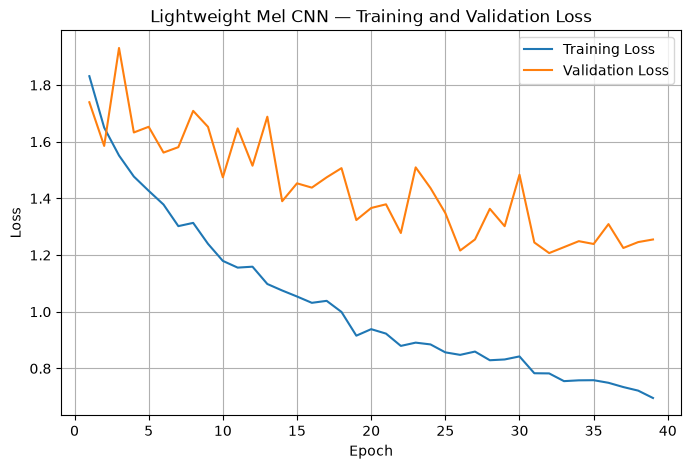

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Lightweight Mel CNN — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

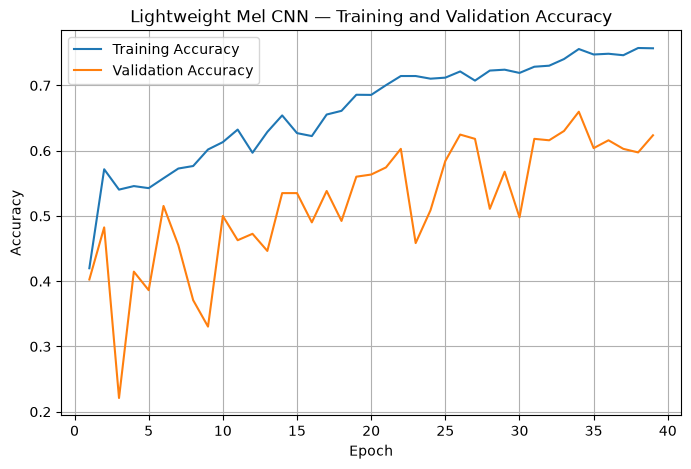

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Lightweight Mel CNN — Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

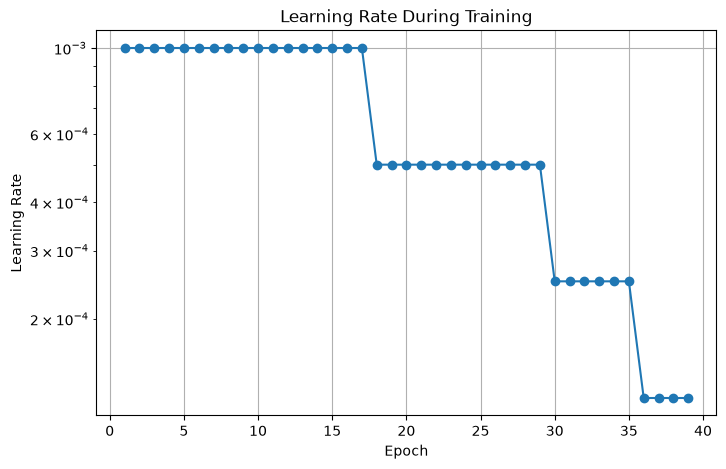

In [94]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate During Training")
plt.yscale("log")
plt.grid(True)

plt.show()

In [95]:
checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

print("Best model loaded.")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Best validation accuracy:", checkpoint["val_accuracy"])

Best model loaded.
Best epoch: 32
Best validation loss: 1.2070167528983018
Best validation accuracy: 0.6159737417943107


In [96]:
model.eval()

with torch.no_grad():
    validation_output = model(
        X_val_batch.to(device)
    )

print("Validation output shape:")
print(validation_output.shape)

assert validation_output.shape[1] == num_classes
assert torch.isfinite(validation_output).all()

print("Best-model validation check PASSED.")

Validation output shape:
torch.Size([32, 8])
Best-model validation check PASSED.


In [97]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_test_labels = []
all_test_predictions = []
all_test_probabilities = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_test_labels.extend(
            y_batch.numpy()
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_probabilities.extend(
            probabilities.cpu().numpy()
        )

y_test_true = np.asarray(
    all_test_labels
)

y_test_pred = np.asarray(
    all_test_predictions
)

y_test_prob = np.asarray(
    all_test_probabilities
)

print("Test samples:", len(y_test_true))
print("Prediction shape:", y_test_pred.shape)
print("Probability shape:", y_test_prob.shape)

Test samples: 1561
Prediction shape: (1561,)
Probability shape: (1561, 8)


In [98]:
assert len(y_test_true) == len(test_cnn_manifest)
assert len(y_test_pred) == len(y_test_true)
assert y_test_prob.shape == (
    len(y_test_true),
    num_classes
)

assert np.isfinite(y_test_prob).all()

print("Test prediction alignment verified.")

Test prediction alignment verified.


In [99]:
test_accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test_true,
    y_test_pred
)

test_macro_precision = precision_score(
    y_test_true,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test_true,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Balanced Accuracy:  {test_balanced_accuracy:.4f}")
print(f"Macro Precision:    {test_macro_precision:.4f}")
print(f"Macro Recall:       {test_macro_recall:.4f}")
print(f"Macro F1:           {test_macro_f1:.4f}")
print(f"Weighted F1:        {test_weighted_f1:.4f}")

Accuracy:           0.7168
Balanced Accuracy:  0.3102
Macro Precision:    0.2130
Macro Recall:       0.2659
Macro F1:           0.2129
Weighted F1:        0.7687


/Users/vs/Sem 5/Respiratory-Disease-Classification/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [100]:
class_names = (
    class_mapping
    .sort_values("disease_label")["diagnosis"]
    .tolist()
)

report = classification_report(
    y_test_true,
    y_test_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = (
    pd.DataFrame(report)
    .T
)

display(classification_report_df)

,precision,recall,f1-score,support
Asthma,0.000000,0.000000,0.000000,0.000000
Bronchiectasis,0.060000,0.150000,0.085714,20.000000
Bronchiolitis,0.073171,0.473684,0.126761,19.000000
COPD,0.956676,0.809274,0.876823,1337.000000
Healthy,0.085106,0.095238,0.089888,84.000000
LRTI,0.000000,0.000000,0.000000,0.000000
Pneumonia,0.272727,0.230769,0.250000,52.000000
URTI,0.043478,0.102041,0.060976,49.000000
accuracy,0.716848,0.716848,0.716848,0.716848
macro avg,0.186395,0.232626,0.186270,1561.000000


In [101]:
per_disease_results = []

for label, disease in enumerate(class_names):

    true_mask = y_test_true == label
    support = int(true_mask.sum())

    disease_precision = precision_score(
        y_test_true,
        y_test_pred,
        labels=[label],
        average="macro",
        zero_division=0
    )

    disease_recall = recall_score(
        y_test_true,
        y_test_pred,
        labels=[label],
        average="macro",
        zero_division=0
    )

    disease_f1 = f1_score(
        y_test_true,
        y_test_pred,
        labels=[label],
        average="macro",
        zero_division=0
    )

    per_disease_results.append({
        "disease_label": label,
        "disease": disease,
        "support": support,
        "precision": disease_precision,
        "recall": disease_recall,
        "f1": disease_f1
    })

per_disease_df = pd.DataFrame(
    per_disease_results
)

display(per_disease_df)

,disease_label,disease,support,precision,recall,f1
0,0,Asthma,0,0.000000,0.000000,0.000000
1,1,Bronchiectasis,20,0.060000,0.150000,0.085714
2,2,Bronchiolitis,19,0.073171,0.473684,0.126761
3,3,COPD,1337,0.956676,0.809274,0.876823
4,4,Healthy,84,0.085106,0.095238,0.089888
5,5,LRTI,0,0.000000,0.000000,0.000000
6,6,Pneumonia,52,0.272727,0.230769,0.250000
7,7,URTI,49,0.043478,0.102041,0.060976


In [102]:
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=np.arange(num_classes)
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)

,Asthma,Bronchiectasis,Bronchiolitis,COPD,Healthy,LRTI,Pneumonia,URTI
Asthma,0,0,0,0,0,0,0,0
Bronchiectasis,0,3,0,17,0,0,0,0
Bronchiolitis,0,0,9,0,0,1,0,9
COPD,0,47,70,1082,57,0,31,50
Healthy,0,0,22,2,8,0,1,51
LRTI,0,0,0,0,0,0,0,0
Pneumonia,0,0,0,25,14,1,12,0
URTI,0,0,22,5,15,2,0,5


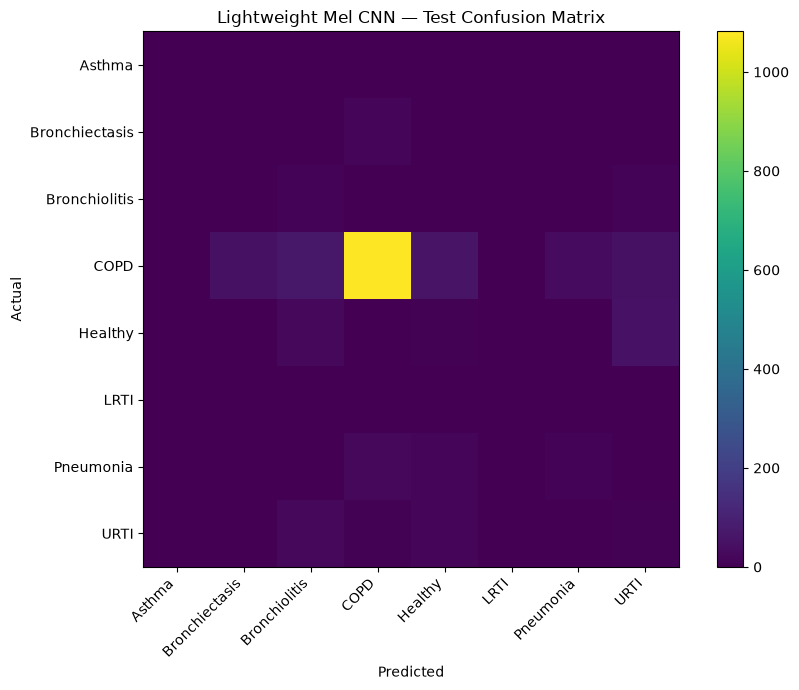

In [103]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.xticks(
    range(num_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(num_classes),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Lightweight Mel CNN — Test Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [104]:
test_predictions_df = test_cnn_manifest.copy()

test_predictions_df["true_label"] = y_test_true
test_predictions_df["predicted_label"] = y_test_pred
test_predictions_df["true_disease"] = [
    class_names[label]
    for label in y_test_true
]
test_predictions_df["predicted_disease"] = [
    class_names[label]
    for label in y_test_pred
]

test_predictions_path = (
    NOTEBOOK_OUTPUT_DIR /
    "cnn_test_predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)

print("Test predictions saved to:")
print(test_predictions_path)

Test predictions saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_test_predictions.csv


In [105]:
baseline_metrics = pd.DataFrame([
    {
        "model": "Lightweight Mel CNN",
        "accuracy": test_accuracy,
        "balanced_accuracy": test_balanced_accuracy,
        "macro_precision": test_macro_precision,
        "macro_recall": test_macro_recall,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "best_epoch": best_epoch,
        "best_validation_loss": best_val_loss,
        "test_samples": len(y_test_true),
        "test_patients": test_cnn_manifest["patient_id"].nunique()
    }
])

baseline_metrics_path = (
    NOTEBOOK_OUTPUT_DIR /
    "cnn_baseline_metrics.csv"
)

baseline_metrics.to_csv(
    baseline_metrics_path,
    index=False
)

display(baseline_metrics)

print("Baseline metrics saved to:")
print(baseline_metrics_path)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_epoch,best_validation_loss,test_samples,test_patients
0,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.21288,0.768721,32,1.207017,1561,25


Baseline metrics saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_baseline_metrics.csv


In [106]:
print("Test patients:",
      test_cnn_manifest["patient_id"].nunique())

print(
    "Train/Test patient overlap:",
    len(
        set(train_cnn_manifest["patient_id"])
        .intersection(
            set(test_cnn_manifest["patient_id"])
        )
    )
)

print(
    "Validation/Test patient overlap:",
    len(
        set(val_cnn_manifest["patient_id"])
        .intersection(
            set(test_cnn_manifest["patient_id"])
        )
    )
)

assert (
    set(train_cnn_manifest["patient_id"])
    .isdisjoint(
        set(test_cnn_manifest["patient_id"])
    )
)

assert (
    set(val_cnn_manifest["patient_id"])
    .isdisjoint(
        set(test_cnn_manifest["patient_id"])
    )
)

print("\nFINAL PATIENT-DISJOINT TEST EVALUATION VERIFIED.")

Test patients: 25
Train/Test patient overlap: 0
Validation/Test patient overlap: 0

FINAL PATIENT-DISJOINT TEST EVALUATION VERIFIED.


## Baseline CNN Results and Interpretation

The Lightweight Mel CNN baseline was trained using Log-Mel spectrograms and a
patient-disjoint train/validation/test split.

The experiment used training-only Gaussian noise and time-shift augmentation,
while validation and test cycles were kept unaugmented. Class weights were
calculated only from the training cycles to reduce the influence of the severe
disease-class imbalance.

The best model was selected using validation loss. Learning-rate reduction and
early stopping were also controlled using validation loss, and the final model
was evaluated only once on the held-out patient-disjoint test set.

### Test Performance

The Lightweight Mel CNN achieved:

- Accuracy: 0.7168
- Balanced Accuracy: 0.3102
- Macro Precision: 0.2130
- Macro Recall: 0.2659
- Macro F1: 0.2129
- Weighted F1: 0.7687

The model selected its best validation-loss checkpoint at epoch 32, with a
validation loss of 1.2070.

The final test set contained 1,561 respiratory cycles from 25 patients, with
zero overlap between the training, validation, and test patient groups.

### Disease-Level Performance

The model performed substantially better for COPD than for the other disease
categories. COPD achieved an F1-score of 0.8768, whereas the F1-scores for
Bronchiectasis, Bronchiolitis, Healthy, Pneumonia, and URTI were considerably
lower.

Asthma and LRTI had zero test support. This occurred because these diseases
have extremely few patients in the ICBHI dataset. The single Asthma patient
and the two LRTI patients were retained in the training set so that these
classes could contribute to model learning. Consequently, their performance
cannot be evaluated on this patient-disjoint test set.

### Interpretation

The difference between the overall accuracy (0.7168) and the much lower
balanced accuracy (0.3102) demonstrates the effect of severe class
imbalance. The high weighted F1-score (0.7687) is also strongly influenced by
the large number of COPD cycles in the test set.

The confusion matrix shows that many non-COPD cycles are incorrectly
classified as COPD. Therefore, although the baseline obtains reasonable
overall accuracy, its ability to distinguish minority respiratory diseases is
limited.

This establishes an important baseline for the subsequent deep-learning
experiments. The purpose of the Lightweight Mel CNN is not necessarily to
achieve the highest performance, but to provide a simple and reproducible
single-feature CNN against which the more advanced multi-feature architecture
can be compared.

The patient-disjoint evaluation also provides a more realistic estimate of
generalization to unseen patients than a cycle-level random split.

In [107]:
experiment_summary = pd.DataFrame([{
    "experiment": "Lightweight Mel CNN Baseline",
    "input": "Log-Mel spectrogram",
    "input_shape": "(1, 64, 157)",
    "split_strategy": "Patient-disjoint",
    "augmentation": "Training only: Gaussian noise + time shift",
    "class_weights": "Training only",
    "model_selection": "Validation loss",
    "early_stopping": "Validation loss",
    "test_patients": test_cnn_manifest["patient_id"].nunique(),
    "test_cycles": len(test_cnn_manifest),
    "accuracy": test_accuracy,
    "balanced_accuracy": test_balanced_accuracy,
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1
}])

experiment_summary_path = (
    NOTEBOOK_OUTPUT_DIR / "cnn_baseline_experiment_summary.csv"
)

experiment_summary.to_csv(
    experiment_summary_path,
    index=False
)

display(experiment_summary)

print("Saved to:")
print(experiment_summary_path)

,experiment,input,input_shape,split_strategy,augmentation,class_weights,model_selection,early_stopping,test_patients,test_cycles,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Lightweight Mel CNN Baseline,Log-Mel spectrogram,"(1, 64, 157)",Patient-disjoint,Training only: Gaussian noise + time shift,Training only,Validation loss,Validation loss,25,1561,0.716848,0.310168,0.213023,0.265858,0.21288,0.768721


Saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/cnn_baseline/cnn_baseline_experiment_summary.csv
